In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

pd.set_option('display.max_columns',None)

In [2]:
PROCESSED = Path("data/processed")
df=pd.read_csv(PROCESSED/"clustering_candidates.csv")

In [3]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])
df.head()

Rows: 16865
Columns: 29


,customer_id,total_orders,total_revenue,average_order_value,median_spend,max_spend,total_discount,avg_discount_percent,completed_orders,returned_orders,rto_orders,payment_diversity,category_diversity,size_diversity,color_diversity,vendor_diversity,return_rate,total_sessions,total_product_views,total_add_to_cart,total_checkout,total_purchases,website_revenue,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,revenue_per_session,customer_lifetime_value,loyalty_score
0,CUST-0000001,1,3356.0,3356.0,3356.0,3356,307,8.40,0,1,0,1,2,2,2,2,1.0,1.0,4.0,1.0,1.0,1.0,3356.0,0.250000,1.0,1.0,3356.0,3356.0,1
1,CUST-0000003,1,2360.0,2360.0,2360.0,2360,125,5.00,1,0,0,1,1,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2360.0,1
2,CUST-0000004,2,4029.0,2014.5,2014.5,2291,832,17.50,0,2,0,1,2,3,3,3,1.0,4.0,11.0,4.0,4.0,4.0,8058.0,0.363636,1.0,1.0,2014.5,4029.0,2
3,CUST-0000005,1,2581.0,2581.0,2581.0,2581,1003,28.00,1,0,0,1,2,1,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2581.0,1
4,CUST-0000007,2,5365.0,2682.5,2682.5,2994,1314,19.95,0,1,1,2,3,3,2,3,1.0,2.0,4.0,2.0,2.0,2.0,5365.0,0.500000,1.0,1.0,2682.5,5365.0,4


### Separate Customer ID
#### Customer ID identifies the customer but should not be used as a clustering feature.

In [4]:
customer_ids = df["customer_id"].copy()
X=df.drop(columns=["customer_id"])

print("Customer IDs:",len(customer_ids))
print("Features:",X.shape[1])

Customer IDs: 16865
Features: 28


### Feature list:

In [5]:
print("Features used for clustering:\n")
for feature in X.columns:
    print("-",feature)

Features used for clustering:

- total_orders
- total_revenue
- average_order_value
- median_spend
- max_spend
- total_discount
- avg_discount_percent
- completed_orders
- returned_orders
- rto_orders
- payment_diversity
- category_diversity
- size_diversity
- color_diversity
- vendor_diversity
- return_rate
- total_sessions
- total_product_views
- total_add_to_cart
- total_checkout
- total_purchases
- website_revenue
- view_to_cart_rate
- cart_to_checkout_rate
- checkout_to_purchase_rate
- revenue_per_session
- customer_lifetime_value
- loyalty_score


In [8]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
total_orders,16865.0,1.778832,1.110665,1.0,1.00,1.00,2.000000,9.00
total_revenue,16865.0,4506.799704,2952.748135,1350.0,2431.00,3422.00,5688.000000,25649.00
average_order_value,16865.0,2528.301471,531.041725,1350.0,2150.67,2518.00,2874.000000,4234.00
median_spend,16865.0,2524.826949,541.648725,1350.0,2128.00,2513.00,2884.000000,4234.00
max_spend,16865.0,2739.777587,624.981270,1350.0,2273.00,2764.00,3205.000000,4246.00
total_discount,16865.0,865.194782,640.284278,91.0,401.00,687.00,1136.000000,5594.00
avg_discount_percent,16865.0,15.761620,5.112163,5.0,12.10,15.40,19.000000,30.00
completed_orders,16865.0,1.151082,0.960098,0.0,1.00,1.00,2.000000,8.00
returned_orders,16865.0,0.447139,0.639427,0.0,0.00,0.00,1.000000,6.00
rto_orders,16865.0,0.180611,0.414961,0.0,0.00,0.00,0.000000,3.00


### Checking highly skewed features:

In [9]:
skewness=(
    X.skew()
    .sort_values(ascending=False)
)
skewness

loyalty_score                3.008370
rto_orders                   2.195495
total_orders                 1.895700
customer_lifetime_value      1.823030
total_revenue                1.823029
total_discount               1.695760
view_to_cart_rate            1.678026
total_product_views          1.567193
website_revenue              1.516518
returned_orders              1.460407
payment_diversity            1.429850
total_checkout               1.421082
total_purchases              1.421082
total_add_to_cart            1.421082
total_sessions               1.421082
completed_orders             1.313818
color_diversity              1.191154
size_diversity               1.060982
category_diversity           1.035823
vendor_diversity             0.924042
return_rate                  0.621508
avg_discount_percent         0.370753
median_spend                 0.227425
average_order_value          0.220710
max_spend                   -0.070454
revenue_per_session         -0.583593
cart_to_chec

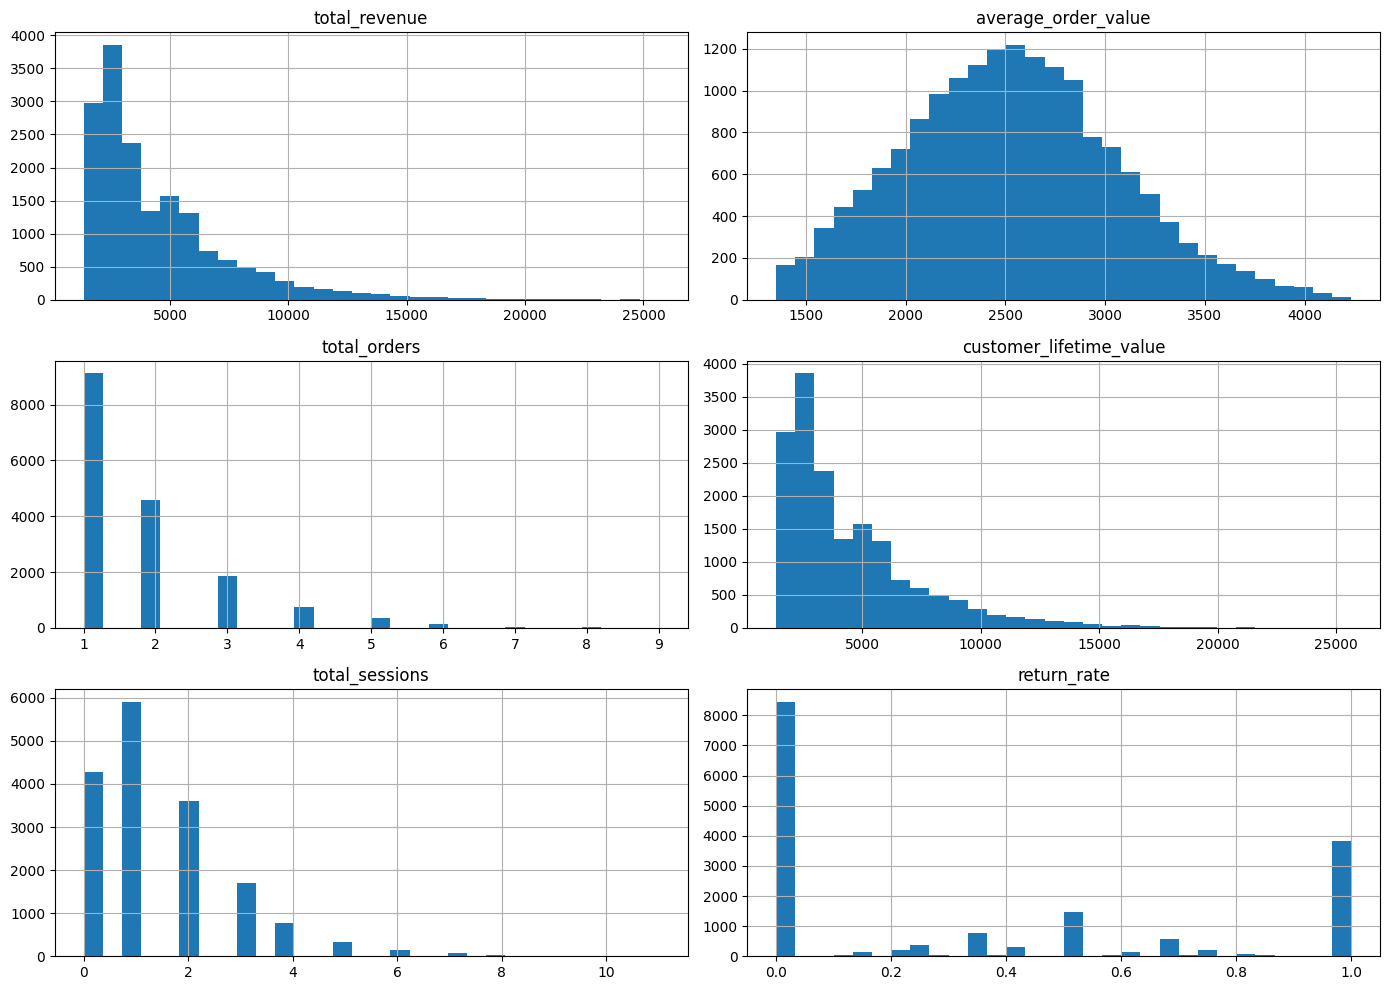

In [10]:
important_features=[
    "total_revenue",
    "average_order_value",
    "total_orders",
    "customer_lifetime_value",
    "total_sessions",
    "return_rate"
]

X[important_features].hist(
    figsize=(14,10),
    bins=30
)

plt.tight_layout()
plt.show()

### handle skewed revenue features:

In [11]:
log_features=[
    "total_revenue",
    "average_order_value",
    "median_spend",
    "max_spend",
    "total_discount",
    "total_sessions",
    "total_product_views",
    "total_add_to_cart",
    "total_checkout",
    "total_purchases",
    "website_revenue",
    "customer_lifetime_value"
]

for col in log_features:
    if col in X.columns:
        X[col]=np.log1p(X[col])

### Standardize features:

In [12]:
scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

X_scaled=pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,total_orders,total_revenue,average_order_value,median_spend,max_spend,total_discount,avg_discount_percent,completed_orders,returned_orders,rto_orders,payment_diversity,category_diversity,size_diversity,color_diversity,vendor_diversity,return_rate,total_sessions,total_product_views,total_add_to_cart,total_checkout,total_purchases,website_revenue,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,revenue_per_session,customer_lifetime_value,loyalty_score
0,-0.701251,-0.214770,1.418203,1.401154,0.952147,-1.104394,-1.440063,-1.198957,0.864645,-0.435260,-0.685219,0.181808,-0.018338,-0.102003,0.094831,1.578691,-0.120729,0.284735,-0.120729,-0.120729,-0.120729,0.520813,-0.118238,0.583627,0.583627,1.213854,-0.214770,-0.580638
1,-0.701251,-0.833109,-0.214067,-0.199374,-0.499439,-2.358059,-2.105164,-0.157366,-0.699302,-0.435260,-0.685219,-0.888418,-0.914751,-0.903627,-0.921907,-0.857637,-1.402236,-1.398019,-1.402236,-1.402236,-1.402236,-1.696236,-1.081389,-1.713424,-1.713424,-1.566552,-0.833109,-0.580638
2,0.199137,0.106237,-0.947823,-0.918861,-0.621767,0.291096,0.340058,-1.198957,2.428593,-0.435260,-0.685219,0.181808,0.878076,0.699620,1.111569,1.578691,1.573330,1.200085,1.573330,1.573330,1.573330,0.759957,0.319558,0.583627,0.583627,0.102437,0.106237,-0.326796
3,-0.701251,-0.675910,0.200903,0.207526,-0.130404,0.552980,2.394044,-0.157366,-0.699302,-0.435260,-0.685219,0.181808,-0.914751,-0.903627,0.094831,-0.857637,-1.402236,-1.398019,-1.402236,-1.402236,-1.402236,-1.696236,-1.081389,-1.713424,-1.713424,-1.566552,-0.675910,-0.580638
4,0.199137,0.609247,0.379719,0.382865,0.481554,0.931462,0.819321,-1.198957,0.864645,1.974675,0.739716,1.252035,0.878076,-0.102003,1.111569,1.578691,0.628904,0.284735,0.628904,0.628904,0.628904,0.648895,0.844914,0.583627,0.583627,0.655867,0.609247,0.180888


### Verify Scaling
#### After standardization, numerical features should have approximately:
##### - Mean=0
##### - Standard deviation=1

In [13]:
X_scaled.describe().T[["mean","std"]]

,mean,std
total_orders,2.696397e-17,1.00003
total_revenue,-5.847811e-16,1.00003
average_order_value,-6.371923e-15,1.00003
median_spend,-1.386117e-15,1.00003
max_spend,-2.170600e-15,1.00003
total_discount,-8.350404e-16,1.00003
avg_discount_percent,-1.676822e-16,1.00003
completed_orders,1.499871e-16,1.00003
returned_orders,-2.991315e-17,1.00003
rto_orders,-5.392794e-17,1.00003


In [14]:
print("Customers:",X_scaled.shape[0])
print("Features:",X_scaled.shape[1])

Customers: 16865
Features: 28


### Elbow method:

In [15]:
inertia=[]

k_values=range(2, 11)

for k in k_values:
    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

### Elbow Method

#### The Elbow Method plots the within-cluster sum of squares (inertia)
#### for different numbers of clusters.

#### We look for a point where adding more clusters gives much smaller improvements.

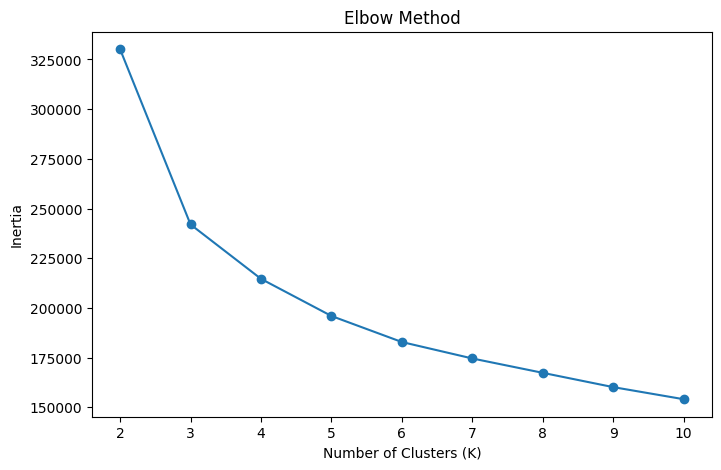

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(k_values)
plt.show()

### Silhouette Score

#### -The Silhouette Score measures how well customers fit within their assigned clusters.
#### -Higher values generally indicate better-separated and more cohesive clusters.

In [17]:
silhouette_scores=[]

for k in k_values:
    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels=model.fit_predict(X_scaled)
    score=silhouette_score(
        X_scaled,
        labels
    )
    silhouette_scores.append(score)

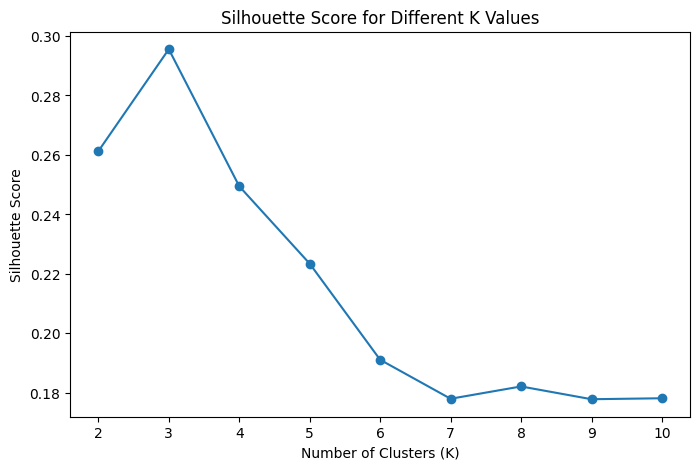

In [18]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.show()

### Sihoutte score results:

In [19]:
silhouette_results = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_scores
})

silhouette_results.sort_values(
    "Silhouette Score",
    ascending=False
)

,K,Silhouette Score
1,3,0.295559
0,2,0.261259
2,4,0.249467
3,5,0.223436
4,6,0.191108
6,8,0.182134
8,10,0.178162
5,7,0.177995
7,9,0.177839


### Davies-Bouldin Score

#### -The Davies-Bouldin Score measures cluster similarity.
#### -Lower values indicate better-defined and better-separated clusters.

In [20]:
db_scores=[]

for k in k_values:
    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels=model.fit_predict(X_scaled)
    score=davies_bouldin_score(
        X_scaled,
        labels
    )
    
    db_scores.append(score)

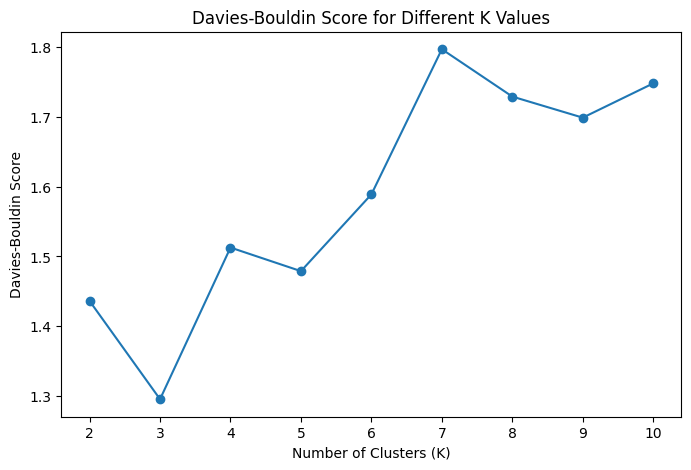

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    db_scores,
    marker="o"
)

plt.title("Davies-Bouldin Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Score")
plt.xticks(k_values)
plt.show()

In [22]:
cluster_metrics=pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores,
    "Davies-Bouldin Score": db_scores
})
cluster_metrics

,K,Inertia,Silhouette Score,Davies-Bouldin Score
0,2,330167.606309,0.261259,1.436142
1,3,241989.668555,0.295559,1.295270
2,4,214635.136883,0.249467,1.512760
3,5,195944.864551,0.223436,1.478918
4,6,182845.019800,0.191108,1.589021
5,7,174572.036805,0.177995,1.797147
6,8,167342.117306,0.182134,1.729239
7,9,160154.883628,0.177839,1.699005
8,10,154071.938173,0.178162,1.748160


### Comparing all clustering matrics:

In [23]:
best_silhouette_k=cluster_metrics.loc[
    cluster_metrics["Silhouette Score"].idxmax(),
    "K"
]

best_db_k=cluster_metrics.loc[
    cluster_metrics["Davies-Bouldin Score"].idxmin(),
    "K"
]

print("Best K by Silhouette Score :",best_silhouette_k)
print("Best K by Davies-Bouldin :",best_db_k)

Best K by Silhouette Score : 3
Best K by Davies-Bouldin : 3


### Choose K

#### The metrics above provide statistical guidance.

#### For this customer segmentation project, we will select a K that:
##### 1. Has a good Silhouette Score.
##### 2. Has a relatively low Davies-Bouldin Score.
##### 3. Is consistent with the Elbow Method.
##### 4. Produces customer groups that can be clearly interpreted.

### Setting KMeans model:

In [26]:
optimal_k=3

kmeans=KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

### Creating clusters:

In [29]:
kmeans_labels=kmeans.fit_predict(X_scaled)

### Adding clusters labels:

In [30]:
clustered_df=df.copy()
clustered_df["cluster"]=kmeans_labels
clustered_df.head()

,customer_id,total_orders,total_revenue,average_order_value,median_spend,max_spend,total_discount,avg_discount_percent,completed_orders,returned_orders,rto_orders,payment_diversity,category_diversity,size_diversity,color_diversity,vendor_diversity,return_rate,total_sessions,total_product_views,total_add_to_cart,total_checkout,total_purchases,website_revenue,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,revenue_per_session,customer_lifetime_value,loyalty_score,cluster
0,CUST-0000001,1,3356.0,3356.0,3356.0,3356,307,8.40,0,1,0,1,2,2,2,2,1.0,1.0,4.0,1.0,1.0,1.0,3356.0,0.250000,1.0,1.0,3356.0,3356.0,1,2
1,CUST-0000003,1,2360.0,2360.0,2360.0,2360,125,5.00,1,0,0,1,1,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2360.0,1,0
2,CUST-0000004,2,4029.0,2014.5,2014.5,2291,832,17.50,0,2,0,1,2,3,3,3,1.0,4.0,11.0,4.0,4.0,4.0,8058.0,0.363636,1.0,1.0,2014.5,4029.0,2,2
3,CUST-0000005,1,2581.0,2581.0,2581.0,2581,1003,28.00,1,0,0,1,2,1,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2581.0,1,0
4,CUST-0000007,2,5365.0,2682.5,2682.5,2994,1314,19.95,0,1,1,2,3,3,2,3,1.0,2.0,4.0,2.0,2.0,2.0,5365.0,0.500000,1.0,1.0,2682.5,5365.0,4,1


### Cluster Size

#### Check how many customers are present in each cluster.
#### This helps us understand whether the clusters are reasonably balanced.

In [31]:
cluster_sizes=(
    clustered_df["cluster"]
    .value_counts()
    .sort_index()
)
cluster_sizes

cluster
0    4277
1    4450
2    8138
Name: count, dtype: int64

### cluster % :

In [32]:
cluster_percentage=(
    clustered_df["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
cluster_percentage

cluster
0    25.36
1    26.39
2    48.25
Name: proportion, dtype: float64

### PCA Visualization:

#### Our clustering uses many features, so it is difficult to visualize directly.
#### PCA reduces the features to two dimensions while preserving as much information as possible.
#### We will use the two principal components to visualize the three clusters.

In [33]:
pca=PCA(
    n_components=2,
    random_state=42
)

X_pca=pca.fit_transform(X_scaled)

print("Explained variance:")
print(pca.explained_variance_ratio_)

Explained variance:
[0.45143386 0.17357241]


### PCA dataframe:

In [34]:
pca_df=pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)
pca_df["cluster"]=kmeans_labels
pca_df.head()

,PC1,PC2,cluster
0,-0.101159,1.125680,2
1,-5.421062,-1.384628,0
2,2.609998,1.882257,2
3,-4.236283,-2.624242,0
4,2.732756,0.049115,1


### PCA cluster visualization:

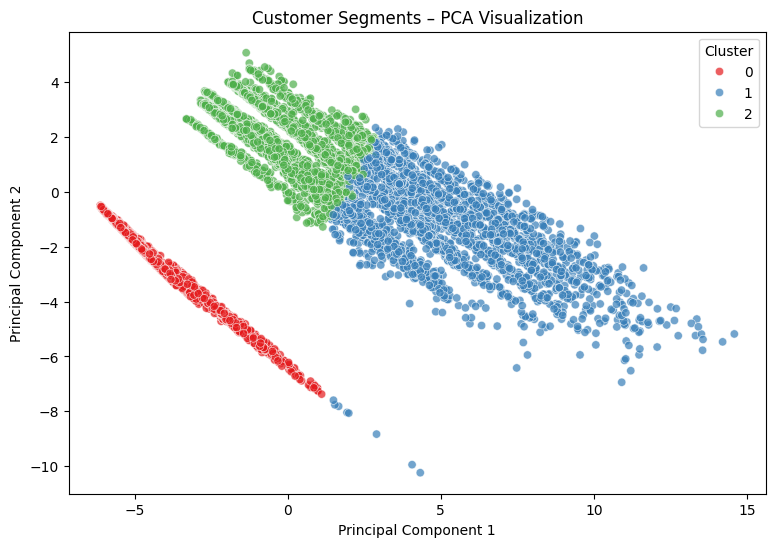

In [35]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    alpha=0.7
)

plt.title("Customer Segments – PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

### PCA explained variance:

In [36]:
explained_variance=pca.explained_variance_ratio_.sum()

print(
    "Variance explained by PC1 + PC2:",
    round(explained_variance * 100, 2),
    "%"
)

Variance explained by PC1 + PC2: 62.5 %


## Cluster Behaviour:
### Cluster-wise Feature Averages

In [38]:
cluster_profile=(
    clustered_df
    .groupby("cluster")
    .mean(numeric_only=True)
    .round(2)
)
cluster_profile

,total_orders,total_revenue,average_order_value,median_spend,max_spend,total_discount,avg_discount_percent,completed_orders,returned_orders,rto_orders,payment_diversity,category_diversity,size_diversity,color_diversity,vendor_diversity,return_rate,total_sessions,total_product_views,total_add_to_cart,total_checkout,total_purchases,website_revenue,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,revenue_per_session,customer_lifetime_value,loyalty_score
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.23,3100.50,2517.34,2517.25,2593.67,600.41,15.88,0.80,0.31,0.12,1.16,1.46,1.55,1.59,1.51,0.35,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.00,3100.50,1.59
1,3.18,8204.21,2605.61,2592.65,3144.88,1585.84,15.88,2.07,0.79,0.32,2.30,2.88,3.32,3.61,3.04,0.35,2.91,9.37,2.91,2.91,2.91,7518.62,0.36,1.0,1.0,2601.15,8204.21,7.81
2,1.30,3224.09,2491.78,2491.72,2595.05,610.29,15.63,0.84,0.33,0.13,1.20,1.45,1.56,1.59,1.49,0.35,1.45,4.61,1.45,1.45,1.45,3604.16,0.39,1.0,1.0,2496.21,3224.09,1.71


### Key features:

In [39]:
key_features=[
    "total_orders",
    "total_revenue",
    "average_order_value",
    "total_discount",
    "return_rate",
    "total_sessions",
    "website_revenue",
    "customer_lifetime_value",
    "loyalty_score"
]
cluster_profile[key_features]

,total_orders,total_revenue,average_order_value,total_discount,return_rate,total_sessions,website_revenue,customer_lifetime_value,loyalty_score
cluster,,,,,,,,,
0,1.23,3100.50,2517.34,600.41,0.35,0.00,0.00,3100.50,1.59
1,3.18,8204.21,2605.61,1585.84,0.35,2.91,7518.62,8204.21,7.81
2,1.30,3224.09,2491.78,610.29,0.35,1.45,3604.16,3224.09,1.71


### Cluster comparison:
#### Visualize cluster revenue

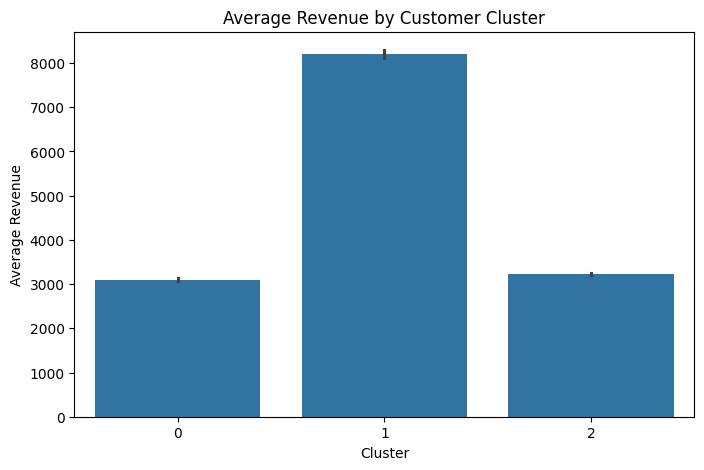

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=clustered_df,
    x="cluster",
    y="total_revenue",
    estimator="mean"
)
plt.title("Average Revenue by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Revenue")
plt.show()

### Visualize customer lifetime value:

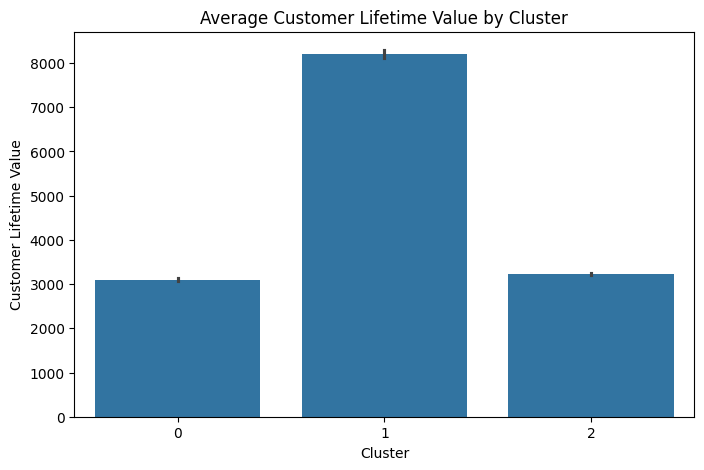

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=clustered_df,
    x="cluster",
    y="customer_lifetime_value",
    estimator="mean"
)

plt.title("Average Customer Lifetime Value by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customer Lifetime Value")
plt.show()

In [42]:
kmeans_silhouette=silhouette_score(
    X_scaled,
    kmeans_labels
)

kmeans_db=davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

print("K-Means Silhouette Score :",round(kmeans_silhouette,3))
print("K-Means Davies-Bouldin:",round(kmeans_db,3))

K-Means Silhouette Score : 0.296
K-Means Davies-Bouldin: 1.295


In [43]:
clustered_df.to_csv(
    PROCESSED/"kmeans_customer_segments.csv",
    index=False
)
print("K-Means customer segments saved successfully..!")

K-Means customer segments saved successfully..!


## Comparing clustring algorithms:
### Agglomerative Clustering starts with each customer as an individual
### cluster and gradually combines similar customers.
### 1)  Hierarchical Clustering:

In [44]:
hierarchical=AgglomerativeClustering(
    n_clusters=3
)
hierarchical_labels=hierarchical.fit_predict(X_scaled)

#### Evaluation of hierarchical clustering:

In [45]:
hierarchical_silhouette=silhouette_score(
    X_scaled,
    hierarchical_labels
)

hierarchical_db=davies_bouldin_score(
    X_scaled,
    hierarchical_labels
)

print("Silhouette Score :",round(hierarchical_silhouette,3))
print("Davies-Bouldin :",round(hierarchical_db,3))

Silhouette Score : 0.279
Davies-Bouldin : 1.329


In [46]:
pd.Series(hierarchical_labels).value_counts().sort_index()

0    6908
1    4285
2    5672
Name: count, dtype: int64

## 2) DBSCAN:

#### -DBSCAN groups customers based on density rather than requiring
#### a fixed number of clusters.

#### -It can also identify unusual customers as noise.

#### -For DBSCAN, the number of clusters does not need to be specified.

In [47]:
dbscan=DBSCAN(
    eps=1.5,
    min_samples=10
)
dbscan_labels=dbscan.fit_predict(X_scaled)

### DBSCAN clusters:

In [48]:
dbscan_counts=(
    pd.Series(dbscan_labels)
    .value_counts()
    .sort_index()
)
dbscan_counts

-1     6112
 0      760
 1     2220
 2      302
 3     2116
 4     1066
 5      135
 6      317
 7       78
 8      844
 9      303
 10      92
 11     364
 12     503
 13     227
 14     330
 15     158
 16     274
 17      96
 18     116
 19      94
 20      49
 21      63
 22      67
 23      25
 24      46
 25      10
 26      40
 27      24
 28      14
 29      11
 30       9
Name: count, dtype: int64

### Evaluation of DBSCAN:

In [49]:
dbscan_mask=dbscan_labels != -1

dbscan_clusters=set(dbscan_labels[dbscan_mask])

if len(dbscan_clusters)>=2:
    dbscan_silhouette=silhouette_score(
        X_scaled[dbscan_mask],
        dbscan_labels[dbscan_mask]
    )

    dbscan_db=davies_bouldin_score(
        X_scaled[dbscan_mask],
        dbscan_labels[dbscan_mask]
    )

    print(
        "Silhouette Score:",
        round(dbscan_silhouette,3)
    )

    print(
        "Davies-Bouldin:",
        round(dbscan_db,3)
    )

else:
    dbscan_silhouette=np.nan
    dbscan_db=np.nan

    print("DBSCAN did not produce enough clusters for evaluation.")

Silhouette Score: 0.101
Davies-Bouldin: 2.04


### 3) Model comparison:

In [50]:
model_comparison=pd.DataFrame({
    "Model":[
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Silhouette Score":[
        kmeans_silhouette,
        hierarchical_silhouette,
        dbscan_silhouette
    ],
    "Davies-Bouldin Score":[
        kmeans_db,
        hierarchical_db,
        dbscan_db
    ]
})
model_comparison.round(3)

,Model,Silhouette Score,Davies-Bouldin Score
0,K-Means,0.296,1.295
1,Hierarchical,0.279,1.329
2,DBSCAN,0.101,2.040


### 4) Cluster size comparison:

### Cluster distribution:

In [51]:
print("K-Means:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

print("\nHierarchical:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

print("\nDBSCAN:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

K-Means:
0    4277
1    4450
2    8138
Name: count, dtype: int64

Hierarchical:
0    6908
1    4285
2    5672
Name: count, dtype: int64

DBSCAN:
-1     6112
 0      760
 1     2220
 2      302
 3     2116
 4     1066
 5      135
 6      317
 7       78
 8      844
 9      303
 10      92
 11     364
 12     503
 13     227
 14     330
 15     158
 16     274
 17      96
 18     116
 19      94
 20      49
 21      63
 22      67
 23      25
 24      46
 25      10
 26      40
 27      24
 28      14
 29      11
 30       9
Name: count, dtype: int64


## PCA Visualizations:-

### 1) Hierarchical Clustring:

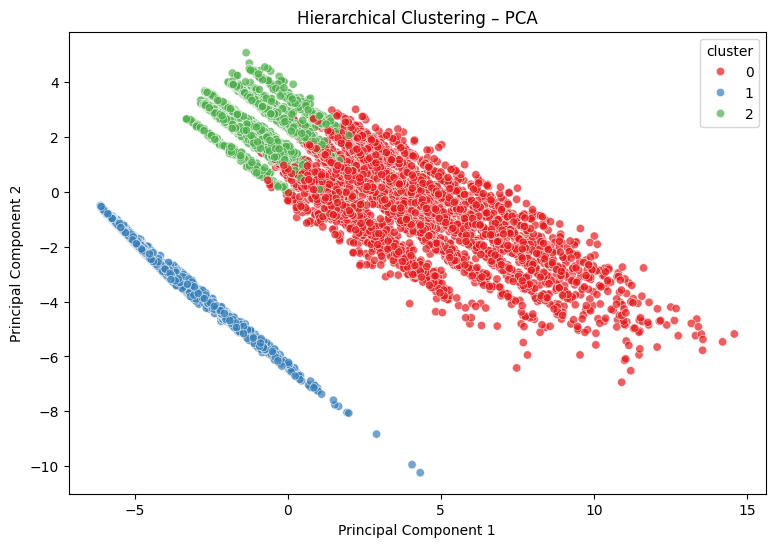

In [52]:
hierarchical_pca=pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

hierarchical_pca["cluster"]=hierarchical_labels

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=hierarchical_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    alpha=0.7
)

plt.title("Hierarchical Clustering – PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### 2) DBSCAN:

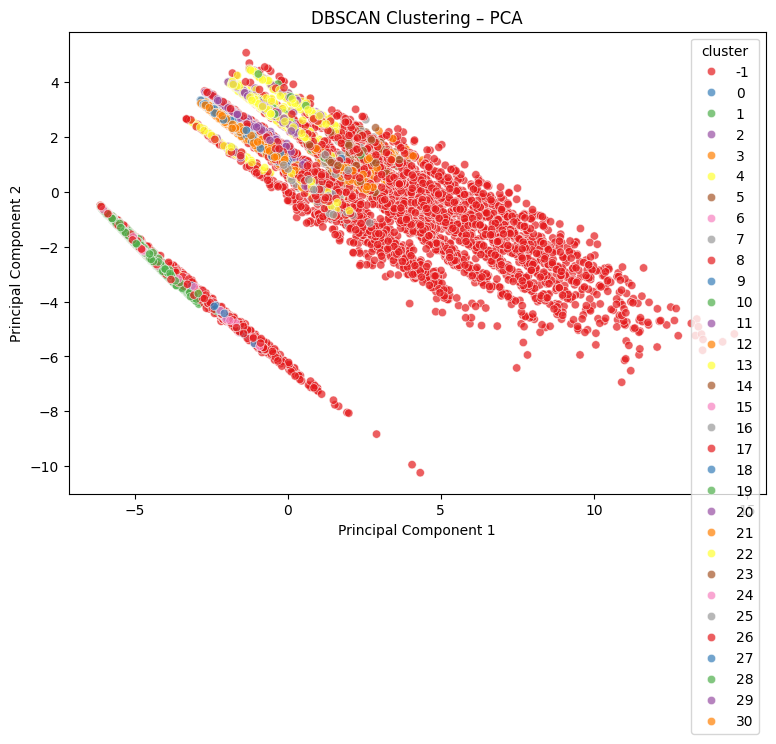

In [53]:
dbscan_pca=pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

dbscan_pca["cluster"]=dbscan_labels

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=dbscan_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    alpha=0.7
)

plt.title("DBSCAN Clustering – PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### The final model will be selected based on:

#### 1. Silhouette Score
#### 2. Davies-Bouldin Score
#### 3. Cluster sizes
#### 4. PCA visualization
#### 5. Business interpretability


In [54]:
model_comparison.sort_values(
    "Silhouette Score",
    ascending=False
).round(3)

,Model,Silhouette Score,Davies-Bouldin Score
0,K-Means,0.296,1.295
1,Hierarchical,0.279,1.329
2,DBSCAN,0.101,2.040


### Final model:

In [55]:
final_labels=kmeans_labels
final_model="K-Means"

print("Final clustering model:",final_model)
print("Number of clusters:",len(np.unique(final_labels)))

Final clustering model: K-Means
Number of clusters: 3


### Final labels:

In [56]:
final_segments=df.copy()
final_segments["cluster"]=final_labels
final_segments.head()

,customer_id,total_orders,total_revenue,average_order_value,median_spend,max_spend,total_discount,avg_discount_percent,completed_orders,returned_orders,rto_orders,payment_diversity,category_diversity,size_diversity,color_diversity,vendor_diversity,return_rate,total_sessions,total_product_views,total_add_to_cart,total_checkout,total_purchases,website_revenue,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,revenue_per_session,customer_lifetime_value,loyalty_score,cluster
0,CUST-0000001,1,3356.0,3356.0,3356.0,3356,307,8.40,0,1,0,1,2,2,2,2,1.0,1.0,4.0,1.0,1.0,1.0,3356.0,0.250000,1.0,1.0,3356.0,3356.0,1,2
1,CUST-0000003,1,2360.0,2360.0,2360.0,2360,125,5.00,1,0,0,1,1,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2360.0,1,0
2,CUST-0000004,2,4029.0,2014.5,2014.5,2291,832,17.50,0,2,0,1,2,3,3,3,1.0,4.0,11.0,4.0,4.0,4.0,8058.0,0.363636,1.0,1.0,2014.5,4029.0,2,2
3,CUST-0000005,1,2581.0,2581.0,2581.0,2581,1003,28.00,1,0,0,1,2,1,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2581.0,1,0
4,CUST-0000007,2,5365.0,2682.5,2682.5,2994,1314,19.95,0,1,1,2,3,3,2,3,1.0,2.0,4.0,2.0,2.0,2.0,5365.0,0.500000,1.0,1.0,2682.5,5365.0,4,1


### Final cluster sizes:

In [57]:
final_segments["cluster"].value_counts().sort_index()

cluster
0    4277
1    4450
2    8138
Name: count, dtype: int64

In [58]:
final_segments.to_csv(
    PROCESSED/"customer_segments.csv",
    index=False
)
print("Final customer segmentation saved..!!")

Final customer segmentation saved..!!
